In [166]:
#import necesassary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error

In [167]:
#Import CSV file
df = pd.read_excel('/content/india_retail_sales.xlsx')

In [168]:
df.head()

,Date,Year,Month,Month_Name,Quarter,City,State,City_Tier,Category,Transaction_Type,Units_Sold,Avg_Price_INR,Discount_Rate,Gross_Sales_INR,Net_Sales_INR,Transactions,Returns,Is_Festival_Month,Trend_Index,Seasonal_Index
0,2024-02-01,2024,2,February,Q1,Guwahati,Assam,Tier 3,Beauty,UPI,269,50.0,0.16,7681.14,6462.43,213,5,0,1.225,0.78
1,2022-01-01,2022,1,January,Q1,Jodhpur,Rajasthan,Tier 3,Sports,Cash,526,50.0,0.10,8423.64,7669.13,414,15,0,1.000,0.82
2,2022-04-01,2022,4,April,Q2,Guwahati,Assam,Tier 3,Beauty,Card,102,50.0,0.15,2326.38,1952.23,79,3,0,1.027,0.84
3,2022-12-01,2022,12,December,Q4,Mumbai,Maharashtra,Tier 1,Clothing,Card,1114,50.0,0.18,27375.48,20894.13,896,30,1,1.055,1.12
4,2024-03-01,2024,3,March,Q1,Indore,Madhya Pradesh,Tier 2,Home & Kitchen,Card,438,50.0,0.11,8585.27,7880.58,338,19,1,1.156,0.88


In [169]:
df.tail()

,Date,Year,Month,Month_Name,Quarter,City,State,City_Tier,Category,Transaction_Type,Units_Sold,Avg_Price_INR,Discount_Rate,Gross_Sales_INR,Net_Sales_INR,Transactions,Returns,Is_Festival_Month,Trend_Index,Seasonal_Index
79995,2024-02-01,2024,2,February,Q1,Indore,Madhya Pradesh,Tier 2,Home & Kitchen,UPI,712,50.00,0.08,17013.48,15241.71,577,20,0,1.150,0.78
79996,2023-10-01,2023,10,October,Q4,Kochi,Kerala,Tier 2,Sports,Cash,594,20.51,0.11,12500.03,11125.02,504,19,1,1.147,1.42
79997,2022-03-01,2022,3,March,Q1,Varanasi,Uttar Pradesh,Tier 3,Electronics,Cash,979,50.00,0.07,25076.66,24508.89,741,44,1,1.016,0.88
79998,2022-02-01,2022,2,February,Q1,Pune,Maharashtra,Tier 2,Clothing,Cash,484,50.00,0.19,11980.46,9266.83,347,18,0,1.005,0.78
79999,2024-11-01,2024,11,November,Q4,Delhi,Delhi,Tier 1,Clothing,UPI,3108,50.00,0.14,65149.33,58125.54,2640,148,1,1.170,1.48


In [170]:
df.isnull().sum()

,0
Date,0
Year,0
Month,0
Month_Name,0
Quarter,0
City,0
State,0
City_Tier,0
Category,0
Transaction_Type,0


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Year               80000 non-null  int64  
 2   Month              80000 non-null  int64  
 3   Month_Name         80000 non-null  object 
 4   Quarter            80000 non-null  object 
 5   City               80000 non-null  object 
 6   State              80000 non-null  object 
 7   City_Tier          80000 non-null  object 
 8   Category           80000 non-null  object 
 9   Transaction_Type   80000 non-null  object 
 10  Units_Sold         80000 non-null  int64  
 11  Avg_Price_INR      80000 non-null  float64
 12  Discount_Rate      80000 non-null  float64
 13  Gross_Sales_INR    80000 non-null  float64
 14  Net_Sales_INR      80000 non-null  float64
 15  Transactions       80000 non-null  int64  
 16  Returns            800

In [172]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_INR,Discount_Rate,Gross_Sales_INR,Net_Sales_INR,Transactions,Returns,Is_Festival_Month,Trend_Index,Seasonal_Index
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,2023.004113,6.494862,713.876300,43.760323,0.118227,15301.590732,13603.181247,552.346900,24.383775,0.417100,1.122952,0.996116
std,0.815416,3.458027,589.163418,11.780688,0.030080,12352.411021,11254.197225,458.452362,22.198510,0.493083,0.078101,0.225818
min,2022.000000,1.000000,72.000000,14.880000,0.030000,1268.260000,1115.740000,52.000000,1.000000,0.000000,1.000000,0.780000
25%,2022.000000,3.000000,342.000000,50.000000,0.090000,7401.315000,6504.307500,263.000000,10.000000,0.000000,1.056000,0.820000
50%,2023.000000,6.000000,544.000000,50.000000,0.120000,11750.980000,10303.310000,420.000000,18.000000,0.000000,1.119000,0.880000
75%,2024.000000,10.000000,895.000000,50.000000,0.140000,19175.485000,17040.990000,692.000000,31.000000,1.000000,1.180000,1.120000
max,2024.000000,12.000000,7844.000000,50.000000,0.190000,157003.810000,149812.810000,6463.000000,342.000000,1.000000,1.315000,1.480000


DATA CLEANING

In [173]:
df.City.unique()

array(['Guwahati', 'Jodhpur', 'Mumbai', 'Indore', 'Patna', 'Lucknow',
       'Jabalpur', 'Mysuru', 'Visakhapatnam', 'Thiruvananthapuram',
       'Delhi', 'Surat', 'Chandigarh', 'Varanasi', 'Raipur', 'Ahmedabad',
       'Meerut', 'Ranchi', 'Chennai', 'Bhopal', 'Kolkata', 'Coimbatore',
       'Amritsar', 'Jaipur', 'Agra', 'Madurai', 'Kochi', 'Bengaluru',
       'Hyderabad', 'Nashik', 'Nagpur', 'Pune', 'Vadodara'], dtype=object)

In [174]:
df.columns.unique()

Index(['Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'City', 'State',
       'City_Tier', 'Category', 'Transaction_Type', 'Units_Sold',
       'Avg_Price_INR', 'Discount_Rate', 'Gross_Sales_INR', 'Net_Sales_INR',
       'Transactions', 'Returns', 'Is_Festival_Month', 'Trend_Index',
       'Seasonal_Index'],
      dtype='object')

EDA

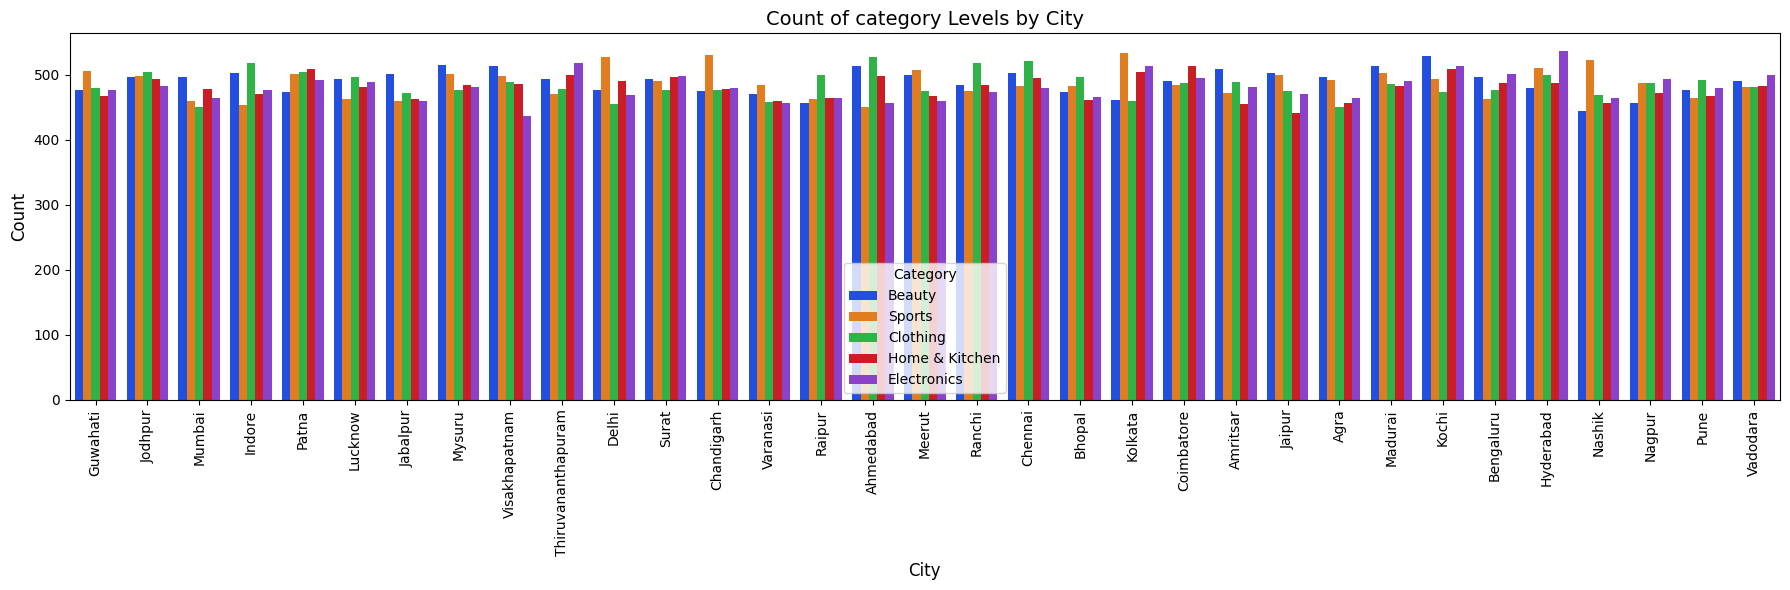

In [175]:
#Countplot
plt.figure(figsize=(18,6))
sns.countplot(data=df, x='City', hue='Category', palette='bright')
plt.title("Count of category Levels by City", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

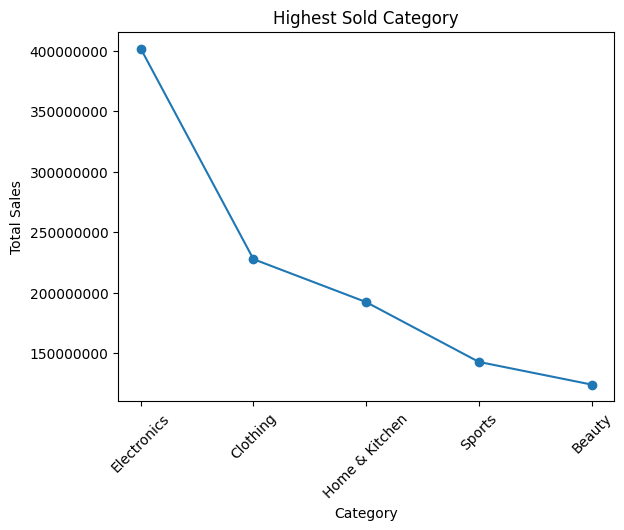

In [176]:
category_sales = (
    df.groupby('Category')['Net_Sales_INR']
      .sum()
      .sort_values(ascending=False)
)

plt.figure()
plt.plot(category_sales.index, category_sales.values, marker='o')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Highest Sold Category')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

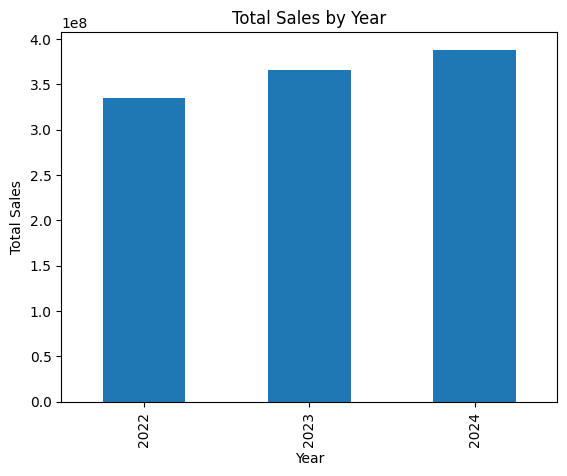

In [177]:
#bar chat
yearly_sales = df.groupby('Year')['Net_Sales_INR'].sum()
yearly_sales.plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Year')
plt.show()

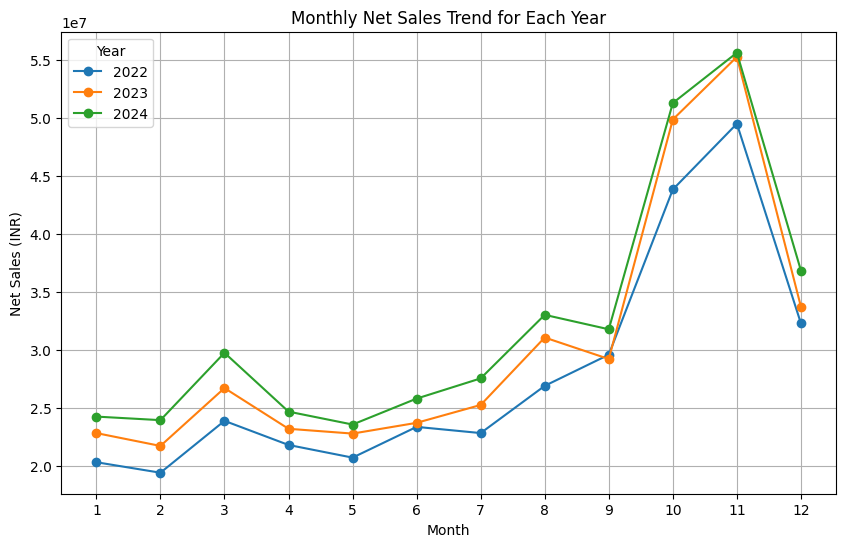

In [178]:
plt.figure(figsize=(10,6))
monthly_trend = (
    df.groupby(['Year', 'Month'])['Net_Sales_INR']
      .sum()
      .reset_index()
      .sort_values(['Year', 'Month'])
)


for year in monthly_trend['Year'].unique():
    year_data = monthly_trend[monthly_trend['Year'] == year]
    plt.plot(
        year_data['Month'],
        year_data['Net_Sales_INR'],
        marker='o',
        label=year
    )

plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Net Sales (INR)')
plt.title('Monthly Net Sales Trend for Each Year')
plt.legend(title='Year')
plt.grid(True)
plt.show()

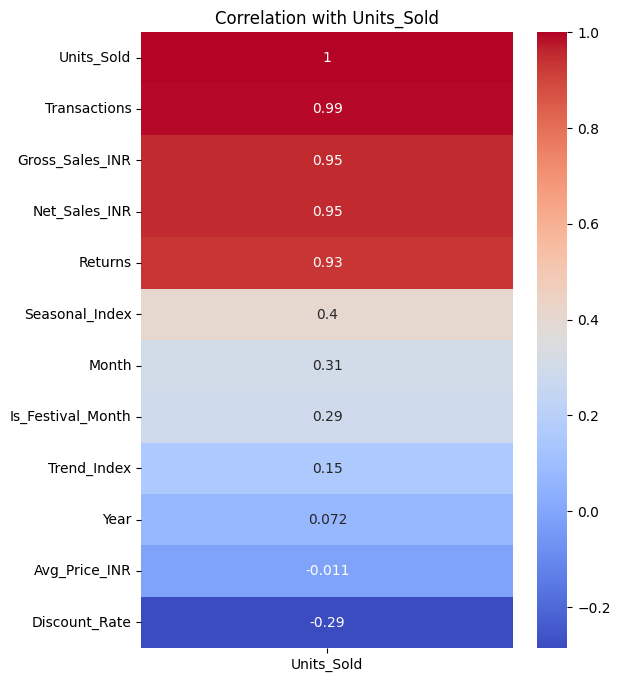

In [179]:
corr = df.corr(numeric_only=True)
corr_target = corr[['Units_Sold']].sort_values(by='Units_Sold', ascending=False)

plt.figure(figsize=(6,8))

sns.heatmap(corr_target,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation with Units_Sold")
plt.show()

FEATURE ENGINEERING

In [180]:
df

,Date,Year,Month,Month_Name,Quarter,City,State,City_Tier,Category,Transaction_Type,Units_Sold,Avg_Price_INR,Discount_Rate,Gross_Sales_INR,Net_Sales_INR,Transactions,Returns,Is_Festival_Month,Trend_Index,Seasonal_Index
0,2024-02-01,2024,2,February,Q1,Guwahati,Assam,Tier 3,Beauty,UPI,269,50.00,0.16,7681.14,6462.43,213,5,0,1.225,0.78
1,2022-01-01,2022,1,January,Q1,Jodhpur,Rajasthan,Tier 3,Sports,Cash,526,50.00,0.10,8423.64,7669.13,414,15,0,1.000,0.82
2,2022-04-01,2022,4,April,Q2,Guwahati,Assam,Tier 3,Beauty,Card,102,50.00,0.15,2326.38,1952.23,79,3,0,1.027,0.84
3,2022-12-01,2022,12,December,Q4,Mumbai,Maharashtra,Tier 1,Clothing,Card,1114,50.00,0.18,27375.48,20894.13,896,30,1,1.055,1.12
4,2024-03-01,2024,3,March,Q1,Indore,Madhya Pradesh,Tier 2,Home & Kitchen,Card,438,50.00,0.11,8585.27,7880.58,338,19,1,1.156,0.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,2024-02-01,2024,2,February,Q1,Indore,Madhya Pradesh,Tier 2,Home & Kitchen,UPI,712,50.00,0.08,17013.48,15241.71,577,20,0,1.150,0.78
79996,2023-10-01,2023,10,October,Q4,Kochi,Kerala,Tier 2,Sports,Cash,594,20.51,0.11,12500.03,11125.02,504,19,1,1.147,1.42
79997,2022-03-01,2022,3,March,Q1,Varanasi,Uttar Pradesh,Tier 3,Electronics,Cash,979,50.00,0.07,25076.66,24508.89,741,44,1,1.016,0.88
79998,2022-02-01,2022,2,February,Q1,Pune,Maharashtra,Tier 2,Clothing,Cash,484,50.00,0.19,11980.46,9266.83,347,18,0,1.005,0.78


In [181]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
categorical_cols = ['State','Category','City','City_Tier','Transaction_Type','Quarter']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

import pandas as pd

for col, le in encoders.items():

    mapping_df = pd.DataFrame({
        'Original_Value': le.classes_,
        'Encoded_Value': le.transform(le.classes_)
    })

    print(f"\nMapping for {col}")
    print(mapping_df)


Mapping for State
    Original_Value  Encoded_Value
0   Andhra Pradesh              0
1            Assam              1
2            Bihar              2
3     Chhattisgarh              3
4            Delhi              4
5          Gujarat              5
6        Jharkhand              6
7        Karnataka              7
8           Kerala              8
9   Madhya Pradesh              9
10     Maharashtra             10
11          Punjab             11
12       Rajasthan             12
13      Tamil Nadu             13
14       Telangana             14
15   Uttar Pradesh             15
16     West Bengal             16

Mapping for Category
   Original_Value  Encoded_Value
0          Beauty              0
1        Clothing              1
2     Electronics              2
3  Home & Kitchen              3
4          Sports              4

Mapping for City
        Original_Value  Encoded_Value
0                 Agra              0
1            Ahmedabad              1
2             Amr

In [182]:
df.head()

,Date,Year,Month,Month_Name,Quarter,City,State,City_Tier,Category,Transaction_Type,Units_Sold,Avg_Price_INR,Discount_Rate,Gross_Sales_INR,Net_Sales_INR,Transactions,Returns,Is_Festival_Month,Trend_Index,Seasonal_Index
0,2024-02-01,2024,2,February,0,9,1,2,0,2,269,50.0,0.16,7681.14,6462.43,213,5,0,1.225,0.78
1,2022-01-01,2022,1,January,0,14,12,2,4,1,526,50.0,0.10,8423.64,7669.13,414,15,0,1.000,0.82
2,2022-04-01,2022,4,April,1,9,1,2,0,0,102,50.0,0.15,2326.38,1952.23,79,3,0,1.027,0.84
3,2022-12-01,2022,12,December,3,20,10,0,1,0,1114,50.0,0.18,27375.48,20894.13,896,30,1,1.055,1.12
4,2024-03-01,2024,3,March,0,11,9,1,3,0,438,50.0,0.11,8585.27,7880.58,338,19,1,1.156,0.88


MODEL TRAINING

In [193]:
x= df[['Year','Quarter','Category','State','City','Transaction_Type']]
y = df['Units_Sold']

In [194]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

MODEL BUILDING

In [201]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [202]:
y_pred = model.predict(x_test)

MODEL EVALUATION

In [203]:
r2 = r2_score(y_test,y_pred)
r2

0.9000499922449994

In [188]:
mse = mean_squared_error(y_test,y_pred)
mse

33668.44183055798

In [189]:
rmse = root_mean_squared_error(y_test,y_pred)
rmse

183.48962322310757